In [1]:
import pandas as pd

# Step 1: Load your Excel file
file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\GDP1.xlsx"
gdp_sheet = 'Data'            # Sheet containing raw GDP data
countries_sheet = 'countries'  # Sheet containing country list (master)

# Step 2: Load GDP data
df_gdp = pd.read_excel(file_path, sheet_name=gdp_sheet)

# Step 3: Load country list (master order)
df_countries = pd.read_excel(file_path, sheet_name=countries_sheet)

# Rename column to match GDP sheet if needed
df_countries.columns = ['Country Name']

# Step 4: LEFT JOIN (keep all countries)
df_clean = df_countries.merge(
    df_gdp,
    on='Country Name',
    how='left'
)

# Step 5: Save cleaned data to a new sheet in the same Excel file
with pd.ExcelWriter(file_path, mode='a', if_sheet_exists='replace', engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='GDP_Cleaned', index=False)

print(
    "GDP data aligned to country list and saved in sheet 'GDP_Cleaned'. "
    "Shape:", df_clean.shape
)


GDP data aligned to country list and saved in sheet 'GDP_Cleaned'. Shape: (192, 69)


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro

import statsmodels.api as sm


In [3]:
def wide_to_long(df,value_name):
    df = df.rename(columns={df.columns[0]: "country"})
    return df.melt(
        id_vars="country",
        var_name="year",
        value_name=value_name
    )

gdp = wide_to_long(pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\GDP1.xlsx", sheet_name="GDP_Cleaned"), value_name="GDP")

In [4]:
# Melt to long format
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\GDP1.xlsx", sheet_name="GDP_Cleaned")

gdp_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="GDP_Growth"
)

# Convert Year to int and GDP_Growth to float
gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long["GDP_Growth"] = pd.to_numeric(gdp_long["GDP_Growth"], errors='coerce')

In [5]:
print(gdp_long)

      Country Name Country Code         Indicator Name     Indicator Code  \
0      Afghanistan          AFG  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
1          Albania          ALB  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
2          Algeria          DZA  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
3          Andorra          AND  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
4           Angola          AGO  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
...            ...          ...                    ...                ...   
12475      Vietnam          VNM  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12476        Yemen          YEM  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12477       Zambia          ZMB  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12478     Zimbabwe          ZWE  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12479    Palestine          NaN                    NaN                NaN   

       Year  GDP_Growth  
0      1960         NaN  
1      1960         NaN

In [6]:

# Calculate % of NaN values in GDP_Growth for each country
nan_percent = gdp_long.groupby("Country Name")["GDP_Growth"].apply(lambda x: x.isna().mean() * 100)

# Sort descending to see countries with most missing values first
nan_percent = nan_percent.sort_values(ascending=False)

print(nan_percent)


Country Name
Cabo Verde       100.000000
Congo            100.000000
North Korea      100.000000
Kyrgyzstan       100.000000
Palestine        100.000000
                    ...    
United States      1.538462
Uruguay            1.538462
Venezuela          1.538462
Zambia             1.538462
Zimbabwe           1.538462
Name: GDP_Growth, Length: 192, dtype: float64


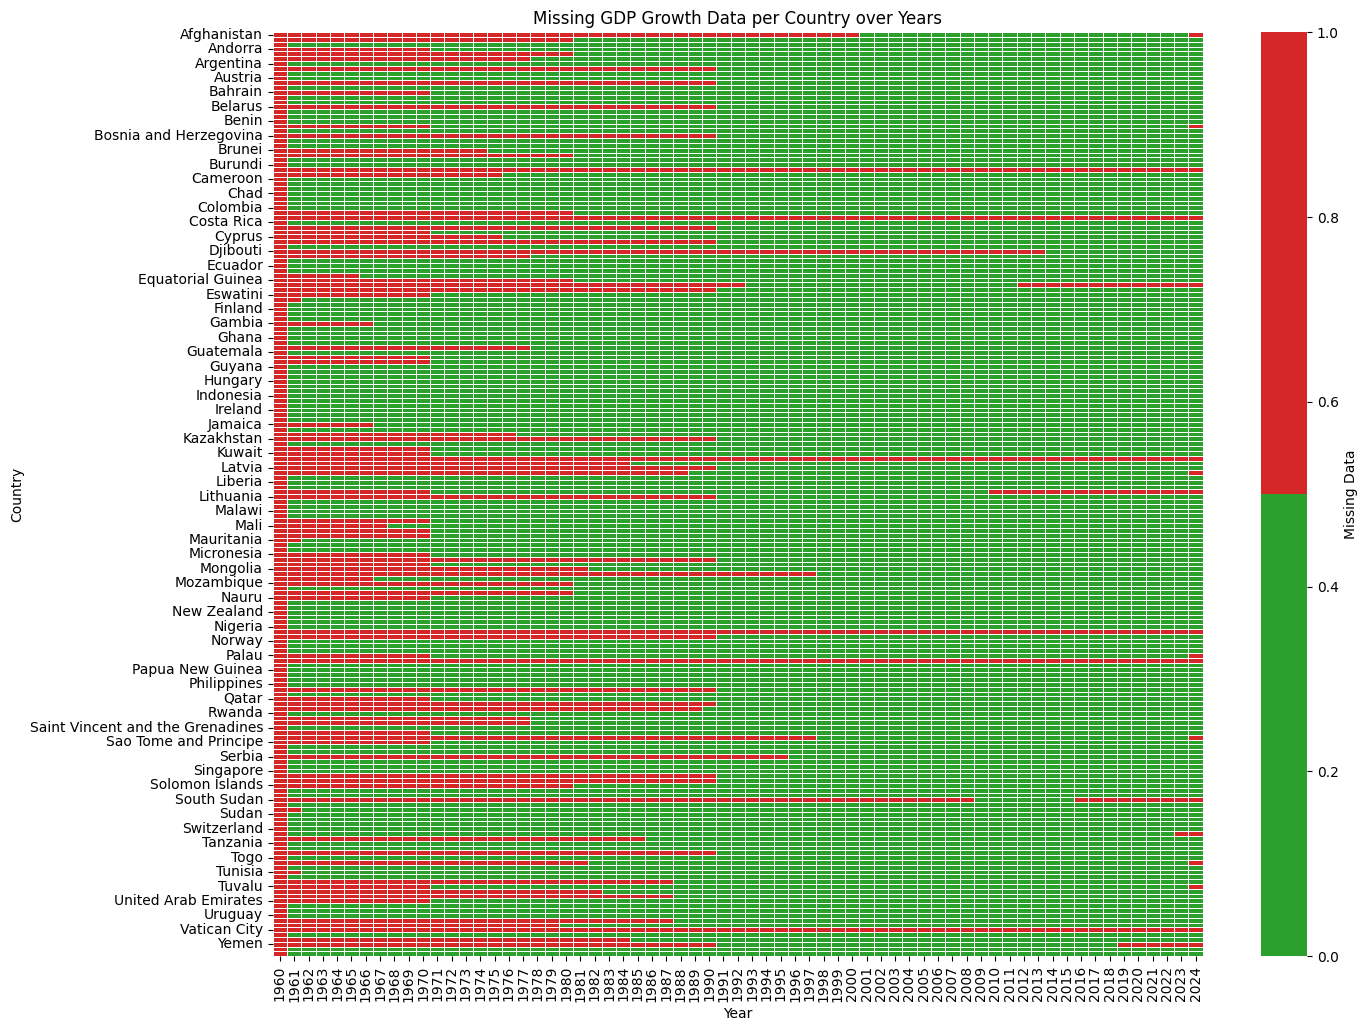

In [7]:
# Pivot data to have countries as rows and years as columns
gdp_pivot = gdp_long.pivot(index="Country Name", columns="Year", values="GDP_Growth")

# Create a boolean mask: True = missing, False = present
missing_mask = gdp_pivot.isna()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(missing_mask, cmap=["#2ca02c", "#d62728"], cbar_kws={'label': 'Missing Data'}, linewidths=0.5)
plt.title("Missing GDP Growth Data per Country over Years")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

MCAR assumption is violated
(Missing Completely At Random is false)

In [8]:
valid_countries = gdp_long.groupby("Country Name")["GDP_Growth"].apply(lambda x: x.notna().sum() > 0)
gdp_clean = gdp_long[gdp_long["Country Name"].isin(valid_countries[valid_countries].index)]
gdp_clean = gdp_clean.dropna(subset=["GDP_Growth"])
print(f"After removing countries with all NaN values, data shape: {gdp_clean.shape}")
print(gdp_clean)


After removing countries with all NaN values, data shape: (10177, 6)
      Country Name Country Code         Indicator Name     Indicator Code  \
194        Algeria          DZA  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
198      Argentina          ARG  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
200      Australia          AUS  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
201        Austria          AUT  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
203        Bahamas          BHS  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
...            ...          ...                    ...                ...   
12472      Vanuatu          VUT  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12474    Venezuela          VEN  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12475      Vietnam          VNM  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12477       Zambia          ZMB  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   
12478     Zimbabwe          ZWE  GDP growth (annual %)  NY.GDP.MKTP.KD.ZG   

      

In [9]:
import numpy as np

# Check number of NaNs, inf, -inf
print("NaNs:", gdp_clean["GDP_Growth"].isna().sum())
print("Infinite values:", np.isinf(gdp_clean["GDP_Growth"]).sum())
print("Negative Infinite values:", np.isneginf(gdp_clean["GDP_Growth"]).sum())

NaNs: 0
Infinite values: 0
Negative Infinite values: 0


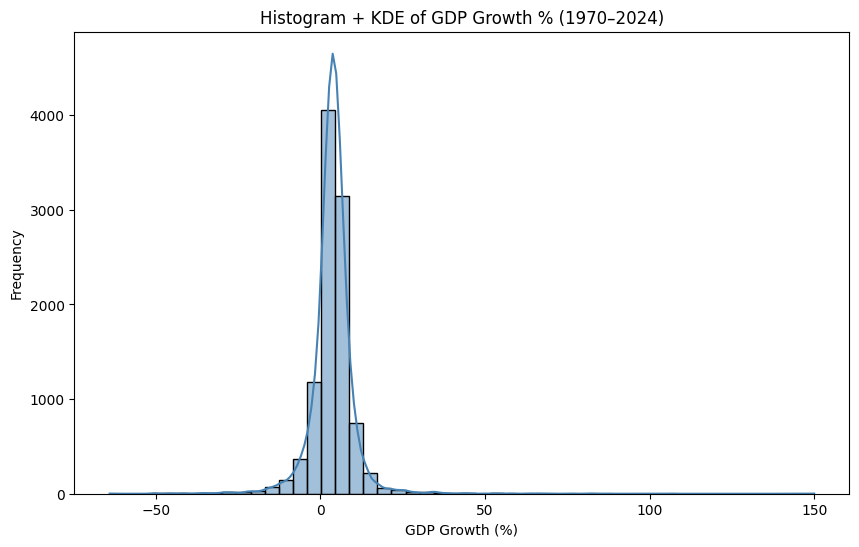

<Figure size 600x600 with 0 Axes>

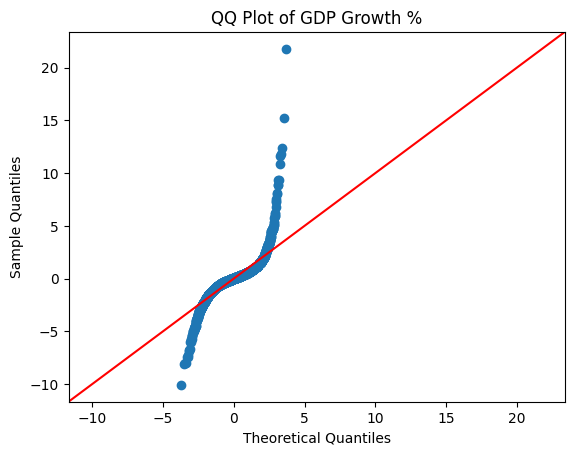

In [10]:

# Histogram + KDE
plt.figure(figsize=(10,6))
sns.histplot(gdp_clean["GDP_Growth"], bins=50, kde=True, color='steelblue')
plt.title("Histogram + KDE of GDP Growth % (1970–2024)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

# QQ Plot
plt.figure(figsize=(6,6))
sm.qqplot(gdp_clean["GDP_Growth"], line='45', fit=True)
plt.title("QQ Plot of GDP Growth %")
plt.show()


In [11]:
skewness = stats.skew(gdp_clean["GDP_Growth"])
kurtosis = stats.kurtosis(gdp_clean["GDP_Growth"])  # excess kurtosis
print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurtosis:.4f}")

Skewness: 1.9340
Excess Kurtosis: 46.4541


In [12]:
from scipy.stats import shapiro, kstest, anderson, norm
import numpy as np


# Kolmogorov-Smirnov Test
mu, sigma = gdp_clean["GDP_Growth"].mean(), gdp_clean["GDP_Growth"].std()
stat, p = kstest(gdp_clean["GDP_Growth"], 'norm', args=(mu, sigma))
print("\nKolmogorov-Smirnov Test")
print(f"Statistic={stat:.4f}, p-value={p:.4f}")

# Anderson-Darling Test
result = anderson(gdp_clean["GDP_Growth"], dist='norm')
print("\nAnderson-Darling Test")
print(f"Statistic={result.statistic:.4f}")
for level, crit in zip(result.significance_level, result.critical_values):
    print(f"  {level}%: {crit:.4f}")



Kolmogorov-Smirnov Test
Statistic=0.1223, p-value=0.0000

Anderson-Darling Test
Statistic=394.8679
  15.0%: 0.5760
  10.0%: 0.6560
  5.0%: 0.7870
  2.5%: 0.9180
  1.0%: 1.0920


Formal normality tests reject the null hypothesis of normality. Given the large sample size (n ≈ 12,000) and the heavy-tailed nature of GDP growth, this result is expected. Therefore, methods assuming strict normality are avoided.

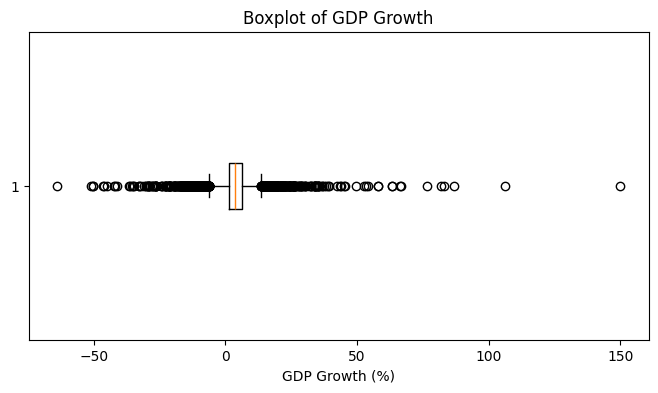

In [13]:
#BOXPLOT
plt.figure(figsize=(8,4))
plt.boxplot(gdp_clean["GDP_Growth"], vert=False)
plt.title("Boxplot of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.show()


The boxplot of GDP growth reveals a highly skewed and heavy-tailed distribution with numerous extreme observations. These values correspond to genuine macroeconomic shocks rather than measurement errors and are therefore retained in the analysis. Robust standard errors and alternative specifications are used to ensure that results are not driven by extreme observations.

In [14]:
Q1 = np.percentile(gdp_clean["GDP_Growth"], 25)
Q3 = np.percentile(gdp_clean["GDP_Growth"], 75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

iqr_outliers = (gdp_clean["GDP_Growth"] < lower_iqr) | (gdp_clean["GDP_Growth"] > upper_iqr)

print("IQR Outliers Count:", iqr_outliers.sum())
print("IQR Outliers %:", iqr_outliers.mean() * 100)


IQR Outliers Count: 771
IQR Outliers %: 7.5759064557335165


Using the IQR criterion, approximately 7.6% of GDP growth observations are classified as outliers. Given the skewed and heavy-tailed nature of macroeconomic growth data, these observations represent genuine economic shocks rather than measurement errors and are therefore retained. Robust estimation techniques are employed to ensure that results are not driven by extreme values.

In [15]:
#EXTREME QUANTILE ANALYSIS
p1, p99 = np.percentile(gdp_clean["GDP_Growth"], [1, 99])

extreme_quantiles = (gdp_clean["GDP_Growth"] < p1) | (gdp_clean["GDP_Growth"] > p99)

print("1–99% Extreme Values Count:", extreme_quantiles.sum())
print("Lower 1% cutoff:", p1)
print("Upper 99% cutoff:", p99)


1–99% Extreme Values Count: 204
Lower 1% cutoff: -15.105581184723707
Upper 99% cutoff: 22.076249537949412


Percentile-based diagnostics indicate that approximately 1.7% of GDP growth observations fall outside the 1st and 99th percentiles (−15.1% and +22.1%, respectively). These values correspond to rare but genuine macroeconomic shocks. All observations are retained in the main analysis, while winsorized specifications are estimated as robustness checks.

In [18]:
import pandas as pd
terror = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Terror.xlsx", sheet_name="Terror_Long_1970_2020")
terror.rename(columns={"Country": "Country Name"}, inplace=True)
panel_df = gdp_long.merge(
    terror,
    on=['Country Name', 'Year'],
    how='left'
)

panel_df['Attacks'] = panel_df['Attacks'].fillna(0)


In [19]:
panel_df = panel_df[
    [
        'Country Name',
        'Country Code',
        'Year',
        'GDP_Growth',
        'Attacks'
    ]
]
df = panel_df[(panel_df['Year'] >= 1970) & (panel_df['Year'] <= 2020)]

print(df)

      Country Name Country Code  Year  GDP_Growth  Attacks
1920   Afghanistan          AFG  1970         NaN      0.0
1921       Albania          ALB  1970         NaN      0.0
1922       Algeria          DZA  1970    8.862657      0.0
1923       Andorra          AND  1970         NaN      0.0
1924        Angola          AGO  1970         NaN      0.0
...            ...          ...   ...         ...      ...
11707      Vietnam          VNM  2020    2.865413      0.0
11708        Yemen          YEM  2020         NaN    474.0
11709       Zambia          ZMB  2020   -2.785055      0.0
11710     Zimbabwe          ZWE  2020   -7.816951      1.0
11711    Palestine          NaN  2020         NaN     61.0

[9792 rows x 5 columns]


In [ ]:
'''terror_sum = df.groupby('Country Code')['Attacks'].sum()

countries_with_terror = terror_sum[terror_sum > 0].index

df = df[df['Country Code'].isin(countries_with_terror)]
print(df)'''

      Country Name Country Code  Year  GDP_Growth  Attacks
1920   Afghanistan          AFG  1970         NaN      0.0
1921       Albania          ALB  1970         NaN      0.0
1922       Algeria          DZA  1970    8.862657      0.0
1923       Andorra          AND  1970         NaN      0.0
1924        Angola          AGO  1970         NaN      0.0
...            ...          ...   ...         ...      ...
11706    Venezuela          VEN  2020  -29.998570      7.0
11707      Vietnam          VNM  2020    2.865413      0.0
11708        Yemen          YEM  2020         NaN    474.0
11709       Zambia          ZMB  2020   -2.785055      0.0
11710     Zimbabwe          ZWE  2020   -7.816951      1.0

[8670 rows x 5 columns]


In [ ]:
'''gdp_missing_pct = (
    df.groupby('Country Code')['GDP_Growth']
      .apply(lambda x: x.isna().mean())
)
print(gdp_missing_pct)'''

Country Code
AFG    0.607843
AGO    0.215686
ALB    0.215686
AND    0.019608
ARE    0.019608
         ...   
VUT    0.196078
YEM    0.450980
ZAF    0.000000
ZMB    0.000000
ZWE    0.000000
Name: GDP_Growth, Length: 170, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

gdp_countries = set(df.loc[df["GDP"].notna(), "Country Name"].unique())
terror_countries = set(df.loc[df["terror_count"].notna(), "Country Name"].unique())

common_countries = gdp_countries.intersection(terror_countries)

print(f"Countries with GDP data: {len(gdp_countries)}")
print(f"Countries with terror data: {len(terror_countries)}")
print(f"Common countries retained: {len(common_countries)}")


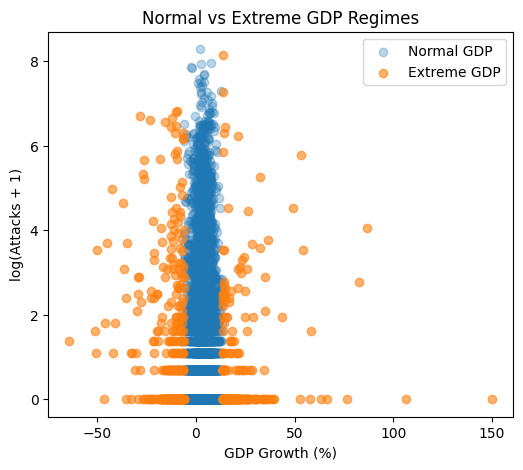

In [25]:
q1 = df['GDP_Growth'].quantile(0.25)
q3 = df['GDP_Growth'].quantile(0.75)
iqr = q3 - q1

df['Extreme_GDP'] = (
    (df['GDP_Growth'] < q1 - 1.5*iqr) |
    (df['GDP_Growth'] > q3 + 1.5*iqr)
)

plt.figure(figsize=(6,5))
plt.scatter(
    df.loc[~df['Extreme_GDP'], 'GDP_Growth'],
    df.loc[~df['Extreme_GDP'], 'log_Attacks'],
    alpha=0.3,
    label='Normal GDP'
)

plt.scatter(
    df.loc[df['Extreme_GDP'], 'GDP_Growth'],
    df.loc[df['Extreme_GDP'], 'log_Attacks'],
    alpha=0.6,
    label='Extreme GDP'
)

plt.legend()
plt.xlabel('GDP Growth (%)')
plt.ylabel('log(Attacks + 1)')
plt.title('Normal vs Extreme GDP Regimes')
plt.show()


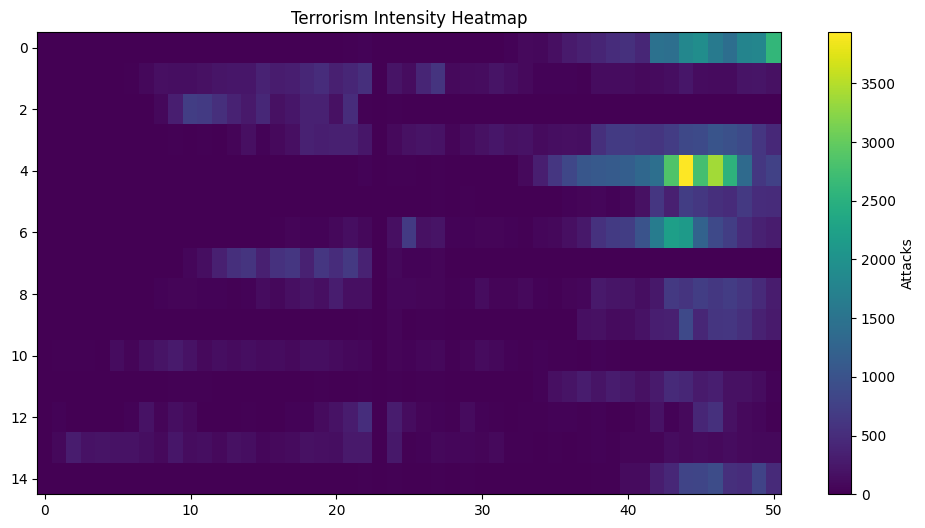

In [26]:
top_countries = (
    df.groupby('Country Name')['Attacks']
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .index
)

heatmap_df = df[df['Country Name'].isin(top_countries)]
pivot = heatmap_df.pivot(
    index='Country Name',
    columns='Year',
    values='Attacks'
)

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Attacks')
plt.title('Terrorism Intensity Heatmap')
plt.show()


KeyError: 'GDP'

In [ ]:
#Aggregated trends reveal global shocks independent of country heterogeneity

global_ts = (
    terror_clean.groupby("year")
      .agg(
          total_terror=("terror_clean", "sum"),
          mean_log_gdp=("log_gdp", "mean")
      )
)

plt.figure()
plt.plot(global_ts.index, global_ts["total_terror"])
plt.xlabel("Year")
plt.ylabel("Total Terror Incidents")
plt.title("Global Terrorism Trend Over Time")
plt.show()
